In [31]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

In [32]:
dir = r'V:\dunwei\MACE\dataset\multirocket_result\multirocket\resample_0\MultiRocket_50000\sr2500_500_1000_20s_logistic_longer_51_41_100pts_20win/'
save_dir = dir

In [33]:
train_thresholds_path = glob.glob(os.path.join(dir, 'train_threshold_cms*.csv'))
test_thresholds_path = glob.glob(os.path.join(dir, 'test_threshold_cms*.csv'))
print(train_thresholds_path)

['V:\\dunwei\\MACE\\dataset\\multirocket_result\\multirocket\\resample_0\\MultiRocket_50000\\sr2500_500_1000_20s_logistic_longer_51_41_100pts_20win\\train_threshold_cms_1.csv', 'V:\\dunwei\\MACE\\dataset\\multirocket_result\\multirocket\\resample_0\\MultiRocket_50000\\sr2500_500_1000_20s_logistic_longer_51_41_100pts_20win\\train_threshold_cms_10.csv', 'V:\\dunwei\\MACE\\dataset\\multirocket_result\\multirocket\\resample_0\\MultiRocket_50000\\sr2500_500_1000_20s_logistic_longer_51_41_100pts_20win\\train_threshold_cms_11.csv', 'V:\\dunwei\\MACE\\dataset\\multirocket_result\\multirocket\\resample_0\\MultiRocket_50000\\sr2500_500_1000_20s_logistic_longer_51_41_100pts_20win\\train_threshold_cms_12.csv', 'V:\\dunwei\\MACE\\dataset\\multirocket_result\\multirocket\\resample_0\\MultiRocket_50000\\sr2500_500_1000_20s_logistic_longer_51_41_100pts_20win\\train_threshold_cms_13.csv', 'V:\\dunwei\\MACE\\dataset\\multirocket_result\\multirocket\\resample_0\\MultiRocket_50000\\sr2500_500_1000_20s_log

In [34]:
all_train_dfs = []
for i, data_path in enumerate(train_thresholds_path):
    train_thresholds_df = pd.read_csv(data_path)
    all_train_dfs.append(train_thresholds_df[['Threshold', 'tn', 'fp', 'fn', 'tp']])
combined_train_df = pd.concat(all_train_dfs)
aggregated_train_df = combined_train_df.groupby('Threshold').sum().reset_index()
aggregated_train_df['Sensitivity'] = aggregated_train_df['tp'] / (aggregated_train_df['tp'] + aggregated_train_df['fn'])
aggregated_train_df['Specificity'] = aggregated_train_df['tn'] / (aggregated_train_df['tn'] + aggregated_train_df['fp'])
display(aggregated_train_df)


all_test_dfs = []
for i, data_path in enumerate(test_thresholds_path):
    test_thresholds_df = pd.read_csv(data_path)
    all_test_dfs.append(test_thresholds_df[['Threshold', 'tn', 'fp', 'fn', 'tp']])
combined_test_df = pd.concat(all_test_dfs)
aggregated_test_df = combined_test_df.groupby('Threshold').sum().reset_index()
aggregated_test_df['Sensitivity'] = aggregated_test_df['tp'] / (aggregated_test_df['tp'] + aggregated_test_df['fn'])
aggregated_test_df['Specificity'] = aggregated_test_df['tn'] / (aggregated_test_df['tn'] + aggregated_test_df['fp'])
display(aggregated_test_df)

,Threshold,tn,fp,fn,tp,Sensitivity,Specificity
0,0.001,214463.0,554497.0,6165.0,154035.0,0.961517,0.278900
1,0.002,289235.0,479725.0,8153.0,152047.0,0.949107,0.376138
2,0.003,339233.0,429727.0,9603.0,150597.0,0.940056,0.441158
3,0.004,376285.0,392675.0,10793.0,149407.0,0.932628,0.489343
4,0.005,405105.0,363855.0,11782.0,148418.0,0.926454,0.526822
...,...,...,...,...,...,...,...
994,0.995,742650.0,26310.0,137498.0,22702.0,0.141710,0.965785
995,0.996,742803.0,26157.0,139127.0,21073.0,0.131542,0.965984
996,0.997,742987.0,25973.0,140899.0,19301.0,0.120481,0.966223
997,0.998,743238.0,25722.0,142842.0,17358.0,0.108352,0.966550


,Threshold,tn,fp,fn,tp,Sensitivity,Specificity
0,0.001,1780.0,6860.0,354.0,1446.0,0.803333,0.206019
1,0.002,2325.0,6315.0,468.0,1332.0,0.740000,0.269097
2,0.003,2670.0,5970.0,562.0,1238.0,0.687778,0.309028
3,0.004,2965.0,5675.0,624.0,1176.0,0.653333,0.343171
4,0.005,3210.0,5430.0,675.0,1125.0,0.625000,0.371528
...,...,...,...,...,...,...,...
994,0.995,8296.0,344.0,1707.0,93.0,0.051667,0.960185
995,0.996,8302.0,338.0,1711.0,89.0,0.049444,0.960880
996,0.997,8304.0,336.0,1712.0,88.0,0.048889,0.961111
997,0.998,8309.0,331.0,1713.0,87.0,0.048333,0.961690


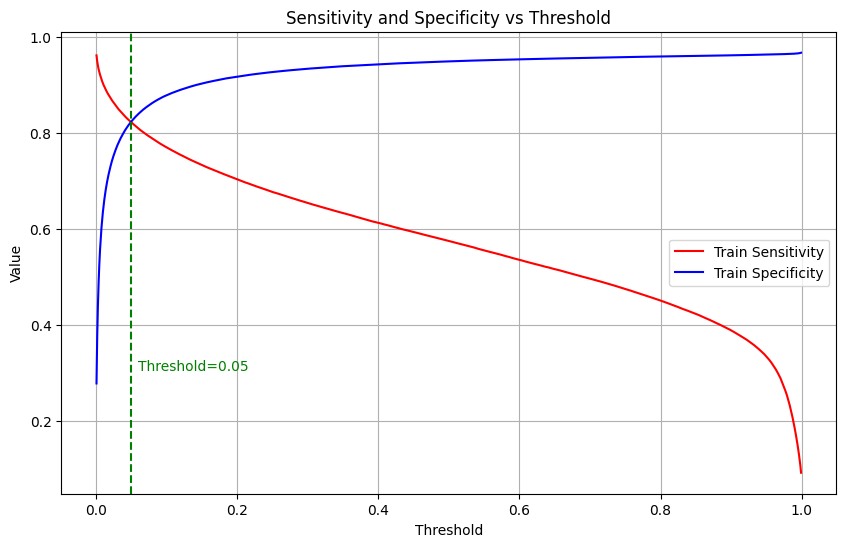

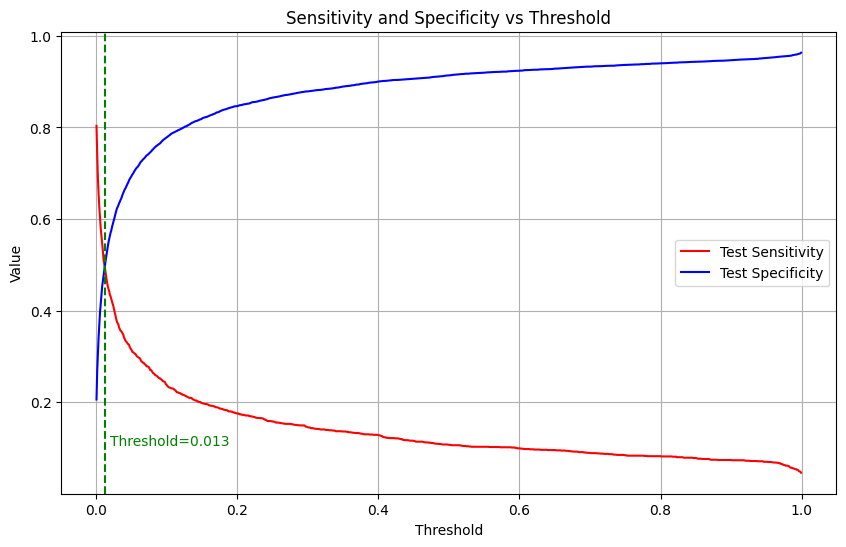

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(aggregated_train_df['Threshold'], aggregated_train_df['Sensitivity'], label='Train Sensitivity', color='red')
plt.plot(aggregated_train_df['Threshold'], aggregated_train_df['Specificity'], label='Train Specificity', color='blue')
plt.xlabel('Threshold')
plt.ylabel('Value')
plt.title('Sensitivity and Specificity vs Threshold')
plt.axvline(x=0.05, color='green', linestyle='--')
plt.text(0.06, 0.3, 'Threshold=0.05', color='green', va='bottom')
plt.legend()
plt.grid()
plt.savefig(os.path.join(save_dir, 'train_sensitivity_specificity_vs_threshold.png'))
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(aggregated_test_df['Threshold'], aggregated_test_df['Sensitivity'], label='Test Sensitivity', color='red')
plt.plot(aggregated_test_df['Threshold'], aggregated_test_df['Specificity'], label='Test Specificity', color='blue')
plt.xlabel('Threshold')
plt.ylabel('Value')
plt.title('Sensitivity and Specificity vs Threshold')
plt.axvline(x=0.013, color='green', linestyle='--')
plt.text(0.02, 0.1, 'Threshold=0.013', color='green', va='bottom')
plt.legend()
plt.grid()
plt.savefig(os.path.join(save_dir, 'test_sensitivity_specificity_vs_threshold.png'))
plt.show()